<a href="https://colab.research.google.com/github/carolina-bolnykh/backend/blob/main/DataScienceWorkshop.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Science for Beginners: NLP in the Legal Domain

## Introduction

## 1. Data Cleaning

### Dataset Introduction
We will use a very simple dataset related to legal documents. Data cleaning is a crucial step in data science to ensure the quality of the data.

### Hands-on Activity: Cleaning the Dataset
Let's start by loading and cleaning our dataset.


In [ ]:
# prompt: extend the above data to have 50 good sentences in each class

import pandas as pd
import re


# Sample dataset
data = {
    'text': [
        'This is a legal document. It contains important information.',
        'Another legal document with different content.',
        'Yet another document, this one is slightly different.',
        'The weather is nice',
        'This is a legal tech presentation'
    ],
    'label': ['legal', 'legal', 'legal', 'non_legal', 'non_legal']
}

df = pd.DataFrame(data)

# Display the dataset
df.head()

# Extend the dataset with more examples
legal_texts = [
    "The plaintiff alleges that the defendant breached the contract.",
    "The court found the defendant liable for damages.",
    "The defendant filed a motion to dismiss the case.",
    "The parties reached a settlement agreement.",
    "The appellate court reversed the lower court's decision.",
    "The Supreme Court heard the case.",
    "The jury found the defendant guilty.",
    "The judge issued an injunction.",
    "The parties engaged in mediation.",
    "The attorney filed a complaint.",
    "The witness testified in court.",
    "The defendant was sentenced to prison.",
    "The plaintiff appealed the decision.",
    "The court ordered the defendant to pay restitution.",
    "The defendant was found not guilty.",
    "The parties entered into a plea bargain.",
    "The court granted summary judgment.",
    "The defendant filed an answer to the complaint.",
    "The plaintiff sought a declaratory judgment.",
    "The court held a hearing.",
    "The defendant filed a counterclaim.",
    "The plaintiff presented evidence at trial.",
    "The court issued a writ of execution.",
    "The defendant was extradited to another state.",
    "The parties entered into arbitration.",
    "The court dismissed the case with prejudice.",
    "The defendant was found in contempt of court.",
    "The plaintiff filed a motion for a new trial.",
    "The court granted a restraining order.",
    "The defendant filed a motion to vacate the judgment.",
    "The plaintiff sought specific performance.",
    "The court ruled that the contract was void.",
    "The defendant was found liable for negligence.",
    "The plaintiff was awarded compensatory damages.",
    "The defendant filed a notice of appeal.",
    "The court remanded the case to the lower court.",
    "The plaintiff sought punitive damages.",
    "The defendant was found liable for strict liability.",
    "The plaintiff was awarded attorney fees.",
    "The defendant filed a motion for a directed verdict.",
    "The court issued a default judgment.",
    "The defendant filed a motion for summary judgment.",
    "The plaintiff sought injunctive relief.",
    "The court held a bench trial.",
    "The defendant was found liable for breach of warranty.",
    "The plaintiff was awarded nominal damages.",
    "The defendant filed a motion to compel discovery."
]

non_legal_texts = [
    "The sun is shining today.",
    "I am going to the store.",
    "The cat is sleeping on the couch.",
    "The dog is barking at the mailman.",
    "The bird is singing in the tree.",
    "The flowers are blooming in the garden.",
    "The children are playing in the park.",
    "The car is driving down the road.",
    "The train is arriving at the station.",
    "The plane is flying in the sky.",
    "The boat is sailing on the water.",
    "The food is delicious.",
    "The movie is interesting.",
    "The music is beautiful.",
    "The book is informative.",
    "The weather is cold.",
    "The temperature is dropping.",
    "The snow is falling.",
    "The wind is blowing.",
    "The rain is pouring.",
    "The sky is cloudy.",
    "The moon is shining.",
    "The stars are twinkling.",
    "The night is dark.",
    "The day is bright.",
    "The world is changing.",
    "The future is uncertain.",
    "The past is gone.",
    "The present is now.",
    "The universe is vast.",
    "The earth is round.",
    "The sun is a star.",
    "The moon is a satellite.",
    "The stars are suns.",
    "The planets are orbiting.",
    "The galaxies are rotating.",
    "The universe is expanding.",
    "The atoms are vibrating.",
    "The molecules are bonding.",
    "The cells are dividing.",
    "The organisms are living.",
    "The ecosystems are evolving.",
    "The species are adapting.",
    "The environment is changing.",
    "The climate is warming.",
    "The oceans are rising.",
    "The ice is melting."
]


new_data = {'text': legal_texts + non_legal_texts, 'label': ['legal'] * len(legal_texts) + ['non_legal'] * len(non_legal_texts)}
new_df = pd.DataFrame(new_data)
df = pd.concat([df, new_df], ignore_index=True)

df.head()


,text,label
0,This is a legal document. It contains importan...,legal
1,Another legal document with different content.,legal
2,"Yet another document, this one is slightly dif...",legal
3,The weather is nice,non_legal
4,This is a legal tech presentation,non_legal


### Cleaning the Text
We will normalize the text by converting it to lowercase and removing punctuation.


In [ ]:
# Function to clean text
def clean_text(text):
    text = text.lower()
    text = re.sub(r'\W', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text

# Apply the cleaning function
df['cleaned_text'] = df['text'].apply(clean_text)

# Display the cleaned dataset
df.head()

,text,label,cleaned_text
0,This is a legal document. It contains importan...,legal,this is a legal document it contains important...
1,Another legal document with different content.,legal,another legal document with different content
2,"Yet another document, this one is slightly dif...",legal,yet another document this one is slightly diff...
3,The weather is nice,non_legal,the weather is nice
4,This is a legal tech presentation,non_legal,this is a legal tech presentation


#2. Data Visualization
Importance of Visualization
Visualization helps in understanding the data better and identifying patterns.

Hands-on Activity: Visualizing the Data
We will visualize the word frequency in our cleaned text.

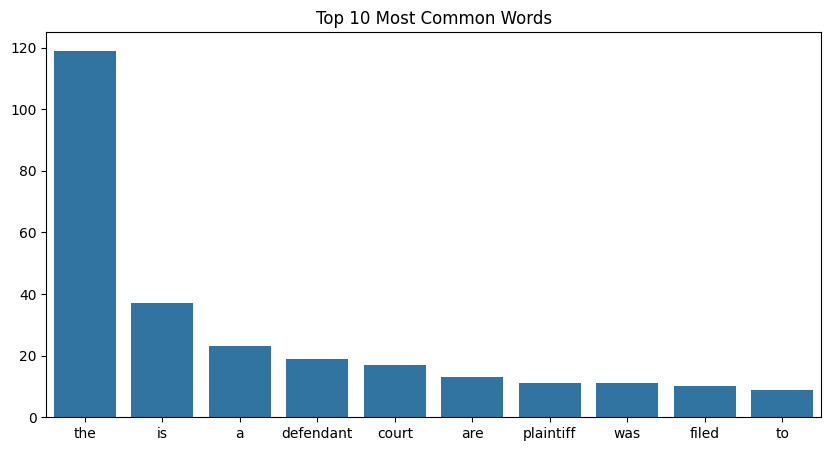

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Word frequency
word_counts = Counter(" ".join(df['cleaned_text']).split())
common_words = word_counts.most_common(10)

# Plot word frequency
words, counts = zip(*common_words)
plt.figure(figsize=(10, 5))
sns.barplot(x=list(words), y=list(counts))
plt.title('Top 10 Most Common Words')
plt.show()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


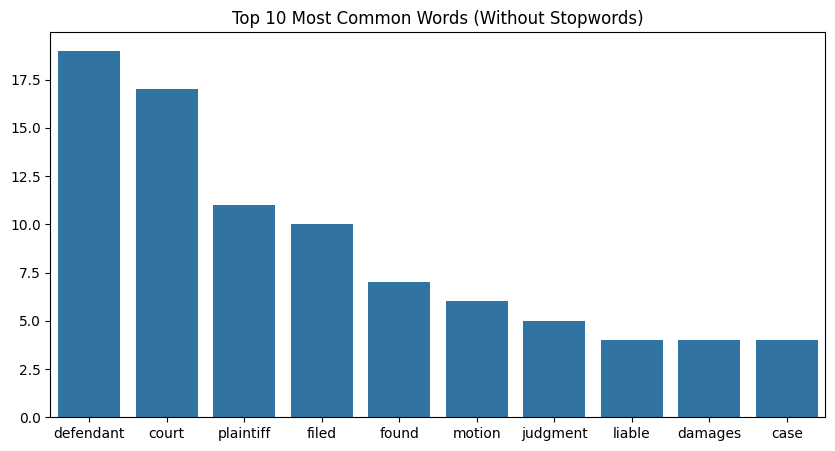

In [ ]:
# prompt: remove stopword then visualize

import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
  tokens = text.split()
  filtered_tokens = [token for token in tokens if token not in stop_words]
  return " ".join(filtered_tokens)

df['cleaned_text_no_stopwords'] = df['cleaned_text'].apply(remove_stopwords)

# Word frequency
word_counts = Counter(" ".join(df['cleaned_text_no_stopwords']).split())
common_words = word_counts.most_common(10)

# Plot word frequency
words, counts = zip(*common_words)
plt.figure(figsize=(10, 5))
sns.barplot(x=list(words), y=list(counts))
plt.title('Top 10 Most Common Words (Without Stopwords)')
plt.show()


#3. Basic Machine Learning Models
Introduction to ML Models
We will build a simple classification model to predict the type of legal document.

Hands-on Activity: Building a Simple Model
We will use the Naive Bayes classifier for this task.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

# Split data
X_train, X_test, y_train, y_test = train_test_split(df['cleaned_text'], df['label'], test_size=0.2, random_state=42)

# Vectorize text
vectorizer = TfidfVectorizer()
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# Train model
model = MultinomialNB()
model.fit(X_train_vec, y_train)

# Predict and evaluate
y_pred = model.predict(X_test_vec)
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy}')

Accuracy: 1.0


#4. Word Embedding models
###word2vec


In [ ]:
# prompt: Visualize word2vec with king queen male female

import gensim.downloader as api
import numpy as np

# Load pre-trained word2vec model
model = api.load("glove-wiki-gigaword-50")

def analogy(word1, word2, word3):
  """
  Computes the analogy: word1 : word2 :: word3 : ?
  """
  try:
    result = model.most_similar(positive=[word3, word2], negative=[word1], topn=1)
    return result[0][0]
  except KeyError:
    return "One or more words not found in the model."

# Perform the king - queen + man analogy
result_word = analogy("king", "queen", "man")
print(f"The analogy result is: {result_word}")



[==================================================] 100.0% 66.0/66.0MB downloaded
The analogy result is: woman


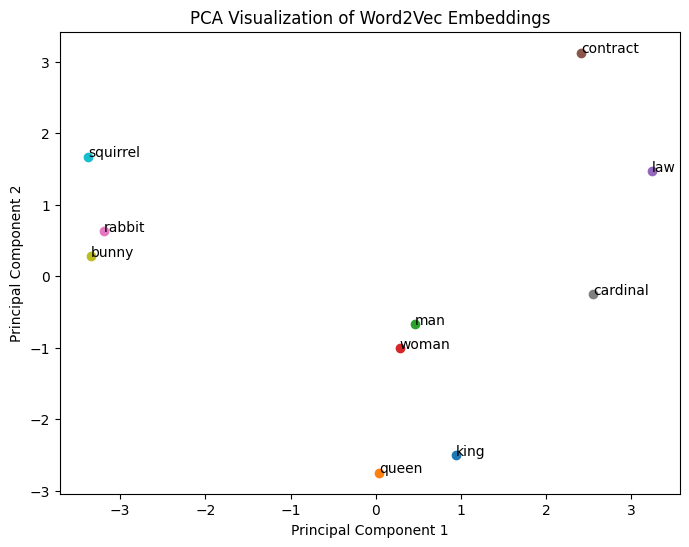

In [ ]:
# prompt: Visualize word2vec with king queen male female with PCA
from sklearn.decomposition import PCA

try:
  model = api.load("glove-wiki-gigaword-50")
except:
  print("Could not download model, ensure you have internet connection")

words = ['king', 'queen', 'man', 'woman', 'law', 'contract', 'rabbit', 'cardinal', 'bunny', 'squirrel']
word_vectors = [model[word] for word in words]

pca = PCA(n_components=2)
word_vectors_pca = pca.fit_transform(word_vectors)

plt.figure(figsize=(8, 6))
for i, word in enumerate(words):
  plt.scatter(word_vectors_pca[i, 0], word_vectors_pca[i, 1])
  plt.annotate(word, (word_vectors_pca[i, 0], word_vectors_pca[i, 1]))

plt.title('PCA Visualization of Word2Vec Embeddings')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()


In [ ]:
# prompt: classify  legal vs non_legal by word2vec

from sklearn.linear_model import LogisticRegression

try:
  model = api.load("glove-wiki-gigaword-50")
except:
  print("Could not download model, ensure you have internet connection")

def get_sentence_embedding(sentence):
  words = sentence.split()
  embeddings = []
  for word in words:
    try:
      embeddings.append(model[word])
    except KeyError:
      pass  # Ignore words not found in the vocabulary
  if not embeddings:
    return np.zeros(model.vector_size)  # Return zero vector if no words are found
  return np.mean(embeddings, axis=0)

df['word2vec_embedding'] = df['cleaned_text'].apply(get_sentence_embedding)

X_train, X_test, y_train, y_test = train_test_split(
    list(df['word2vec_embedding']), df['label'], test_size=0.2, random_state=42
)

clf = LogisticRegression(max_iter=1000)  # Increase max_iter if needed
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy with word2vec embeddings: {accuracy}')


Accuracy with word2vec embeddings: 0.95


In [ ]:
y_pred

array(['non_legal', 'legal', 'non_legal', 'legal', 'non_legal',
       'non_legal', 'non_legal', 'legal', 'legal', 'legal', 'legal',
       'non_legal', 'legal', 'legal', 'legal', 'legal', 'legal', 'legal',
       'non_legal', 'non_legal'], dtype=object)

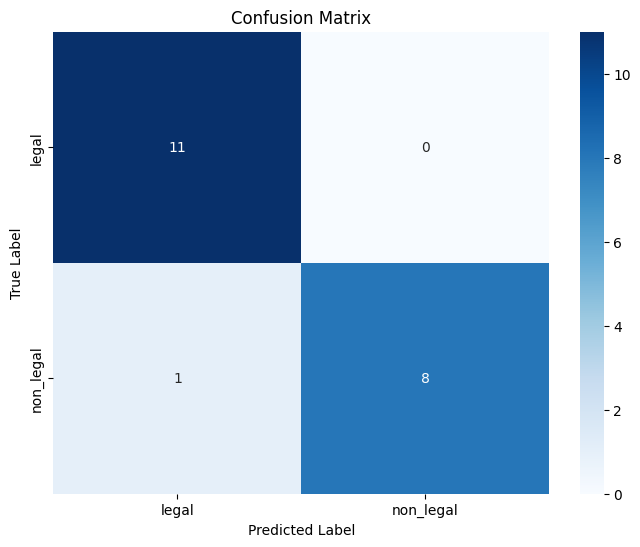

In [ ]:
# prompt: create confusion matrix

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['legal', 'non_legal'], yticklabels=['legal', 'non_legal'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


#5. Transformers

In [ ]:
# prompt: train a bert classifier for legal vs non_legal problem by pytorch

!pip install transformers

import torch
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertForSequenceClassification, AdamW
from sklearn.metrics import accuracy_score
from tqdm import tqdm

# Assuming df is your DataFrame with 'cleaned_text' and 'label' columns

# Define a custom dataset class
class LegalDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

# Load pre-trained BERT tokenizer and model
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2)  # 2 labels: legal and non-legal

# Tokenize the text data
X_train, X_test, y_train, y_test = train_test_split(df['cleaned_text'], df['label'], test_size=0.2, random_state=42)

train_encodings = tokenizer(list(X_train), truncation=True, padding=True)
test_encodings = tokenizer(list(X_test), truncation=True, padding=True)

# Convert labels to numerical values (0 for legal, 1 for non-legal)
label_mapping = {'legal': 0, 'non_legal': 1}
y_train_numerical = [label_mapping[label] for label in y_train]
y_test_numerical = [label_mapping[label] for label in y_test]

# Create datasets
train_dataset = LegalDataset(train_encodings, y_train_numerical)
test_dataset = LegalDataset(test_encodings, y_test_numerical)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

# Set up optimizer and learning rate
optimizer = AdamW(model.parameters(), lr=5e-5)

# Train the model
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
model.to(device)

epochs = 3
for epoch in range(epochs):
    model.train()
    loop = tqdm(train_loader, leave=True)
    for batch in loop:
        optimizer.zero_grad()
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        loss.backward()
        optimizer.step()
        loop.set_description(f'Epoch {epoch}')
        loop.set_postfix(loss=loss.item())

# Evaluate the model
model.eval()
y_pred_list = []
y_true_list = []
with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        outputs = model(input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        y_pred = torch.argmax(logits, dim=1).tolist()
        y_pred_list.extend(y_pred)
        y_true_list.extend(labels.tolist())

accuracy = accuracy_score(y_true_list, y_pred_list)
print(f'Accuracy with BERT: {accuracy}')


/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

/usr/local/lib/python3.10/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.10/dist-packages/transformers/optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(
Epoch 2: 100%|██████████| 5/5 [00:14<00:00,  2.80s/it, loss=0.0867]


Accuracy with BERT: 1.0


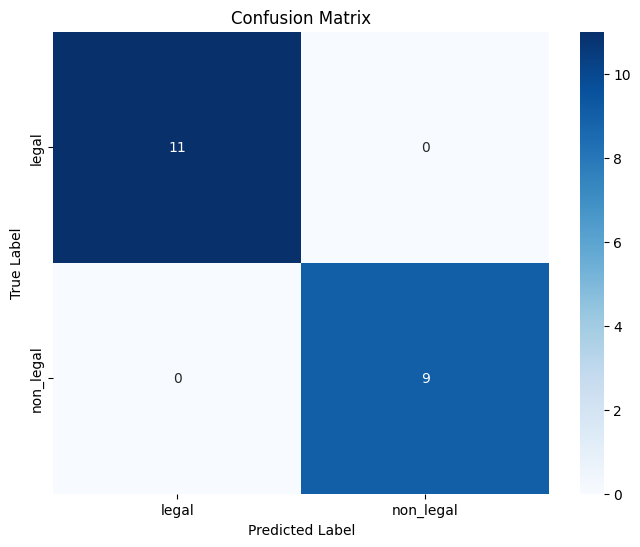

In [ ]:
# prompt: create confusion matrix

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true_list, y_pred_list)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['legal', 'non_legal'], yticklabels=['legal', 'non_legal'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()